In [195]:
%%capture
%pip install datasets transformers

In [196]:
import torch
from torch import nn
import torch.nn.functional as F
from tqdm.notebook import tqdm
from torch.utils.data import DataLoader
import numpy as np
from typing import List, Optional
import unicodedata
import re
import matplotlib.pyplot as plt

# Transformer from scratch

In this notebook we are going to code a GPT model from scratch.

We will do that in a modular way, and increase the difficulty step by step.

&#128308; **WARNING** &#128308; **You are not allowed to use any existing pre-built torch module, like `nn.Linear`.** You can only use pytorch `Tensor` and the module you create.

## Basic transformer block

![](https://drive.google.com/uc?export=view&id=1dlkXQtGtZwoHribpTeQ0MeoNdwoiYJOo)

In this first part, we are going to build the grey block. We are going to write this step by step.

In [197]:
def coef_attention(q_i, k):
    # q_i: (d, 1)
    # k: (n, d)
    # Returns: (n, 1)
    d = q_i.shape[0]
    scores = k @ q_i  # (n, 1)
    scores = scores / (d ** 0.5)
    return torch.softmax(scores, dim=0)

> Notes about the completed code:

**`coef_attention`**: computes `softmax(k @ q_i / sqrt(d))`. The scaling by `sqrt(d)` prevents the dot products from growing large in magnitude, which would push softmax into regions with very small gradients.

Query vector q_i: tensor([[-0.3911],
        [-1.6797],
        [ 0.6805]])
Key matrix k: tensor([[-0.8444,  0.1582,  0.5651],
        [ 1.4827,  0.8164,  0.1889],
        [-0.1928,  1.3867,  0.2496],
        [ 2.2808,  2.2340,  0.1048],
        [ 0.0588,  1.7161, -0.5556]])
Attention coefficients: tensor([[0.5981],
        [0.1611],
        [0.1386],
        [0.0329],
        [0.0693]])


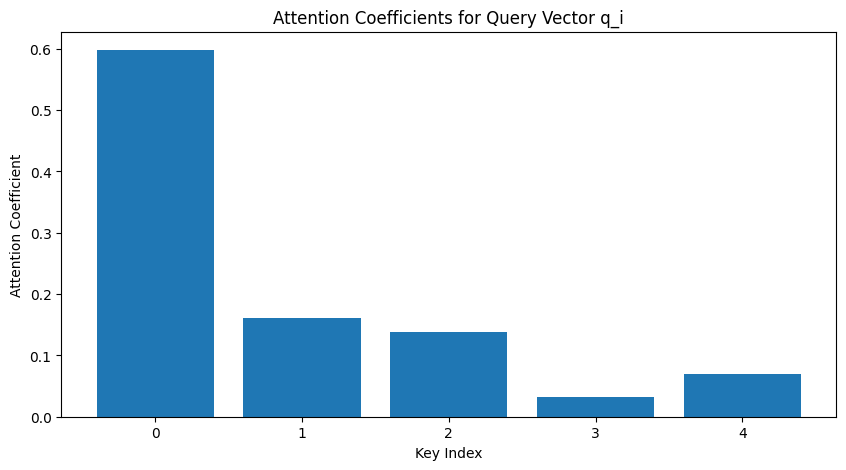

In [198]:
q_i = torch.randn(3, 1)  # Example query vector
print("Query vector q_i:", q_i)
k = torch.randn(5, 3)  # Example key matrix with 5 keys, each of dimension 3
print("Key matrix k:", k)
attention_coefficients = coef_attention(q_i, k)
print("Attention coefficients:", attention_coefficients)
# Visualizing the attention coefficients
plt.figure(figsize=(10, 5))
plt.bar(range(len(attention_coefficients)), attention_coefficients.squeeze().numpy())
plt.xlabel("Key Index")
plt.ylabel("Attention Coefficient")
plt.title("Attention Coefficients for Query Vector q_i")
plt.show()

In [199]:
def attention(q_i, k, v):
    """
    Compute the attention output for a given query vector q_i, key matrix k, and value matrix v.

    Parameters:
    - q_i: Query vector of shape (d, 1)
    - k: Key matrix of shape (n, d)
    - v: Value matrix of shape (n, d)

    Returns:
    - Output vector of shape (d, 1)
    """
    # Compute attention coefficients
    alpha = coef_attention(q_i, k)  # (n, 1)

    # Compute the weighted sum of values
    out = torch.matmul(v.T, alpha)  # (d, 1)

    return out

In [200]:
q_i = torch.randn(3, 1)  # Example query vector
k = torch.randn(5, 3)  # Example key matrix with 5 keys, each of dimension 3
v = torch.randn(5, 3)  # Example value matrix with 5 values, each of dimension 3
print("Query vector q_i:", q_i)
print("Key matrix k:", k)
print("Value matrix v:", v)
attention_output = attention(q_i, k, v)
print("Attention output:", attention_output.shape)

Query vector q_i: tensor([[-2.4459],
        [-1.1718],
        [ 0.4793]])
Key matrix k: tensor([[ 0.3467,  1.2194, -1.4138],
        [-0.7110, -0.4116,  0.5414],
        [-0.0679, -1.0712, -0.5465],
        [-0.8830, -0.1490,  0.1329],
        [ 0.3175,  0.4909, -0.5826]])
Value matrix v: tensor([[-0.8150, -0.6768,  0.5271],
        [ 1.3680, -0.8977,  0.7404],
        [-0.1445, -0.1757,  2.4516],
        [ 0.7283, -0.8209,  0.4673],
        [ 1.0913,  1.9409,  1.5184]])
Attention output: torch.Size([3, 1])


🚧 **TODO** 🚧

Which submodules do we need to write? Propose an architecture for each of them, and keep it as simple as possible.



In [201]:
class Embeddings(nn.Module):
    def __init__(self, vocab_size, d):
        super().__init__()
        embeddings = 0.02 * torch.randn(vocab_size, d)
        self.embeddings = nn.Parameter(embeddings)

    def forward(self, x):
        return self.embeddings[x]


class Linear(nn.Module):
    def __init__(self, d_in, d_out, bias=True):
        super().__init__()
        self.matrix = nn.Parameter(0.02 * torch.randn(d_in, d_out))
        if bias:
            self.bias = nn.Parameter(0.02 * torch.randn(d_out))

    def forward(self, x):
        results = x @ self.matrix
        if hasattr(self, "bias"):
            results += self.bias
        return results


class Attention(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.q_proj = Linear(d, d)
        self.k_proj = Linear(d, d)
        self.v_proj = Linear(d, d)

    def forward(self, x):
        q = self.q_proj(x)  # (b, l, d)
        k = self.k_proj(x)
        v = self.v_proj(x)

        d = k.shape[-1]
        s_ij = q @ k.transpose(1, 2) * d ** (-0.5)  # (b, l, l)

        a_ij = torch.softmax(s_ij, dim=-1)

        y = a_ij @ v  # (b, l, d)
        return y


def ReLU(x):
    return x * (x > 0)


class FeedForward(nn.Module):
    def __init__(self, d_embed, d_ff, dropout=0.1):
        super().__init__()
        self.w1 = Linear(d_embed, d_ff)
        self.w2 = Linear(d_ff, d_embed)
        self.act_fn = ReLU
        self.dropout = dropout

    def forward(self, x):
        z = self.w1(x)
        z = self.act_fn(z)
        z = F.dropout(z, p=self.dropout)
        z = self.w2(z)
        return z

> Notes about the completed code:


**The class `Linear`**: stores a `(d_in, d_out)` weight matrix so that `x @ W` works naturally for batched inputs of shape `(b, l, d_in)`.

🚧 **TODO** 🚧

Embeds this in a `BasicTransformer` class. It should be parametrized by:
- `d_embed` the dimension of the input vectors.

In [202]:
class LayerNorm(nn.Module):
    def __init__(self, d, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.gamma = nn.Parameter(torch.ones(d))
        self.beta = nn.Parameter(torch.zeros(d))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        std = x.std(dim=-1, keepdim=True)
        return self.gamma * (x - mean) / (std + self.eps) + self.beta


class TransformerLayer(nn.Module):
    def __init__(self, d_embed, d_ff, dropout=0.1):
        super().__init__()
        self.attention = Attention(d_embed)
        self.feed_forward = FeedForward(d_embed, d_ff, dropout)

        self.input_layer_norm = LayerNorm(d_embed)
        self.attention_layer_norm = LayerNorm(d_embed)

    def forward(self, x):
        normed_input = self.input_layer_norm(x)
        z = self.attention(normed_input)
        z = z + normed_input
        z = self.attention_layer_norm(z)
        y = self.feed_forward(z)
        return y + z

> Note about TransformerLayer

**`TransformerLayer`**: follows the Pre-LN pattern, layer norm is applied *before* the attention and feed-forward sublayers (rather than after), which tends to be more stable to train. The residual connections (`z + normed_input` and `y + z`) allow gradients to flow directly through the network.

🔴 **TEST**

In [203]:
d_embed = 8
d_ff = 32
batch_size = 4
seq_length = 6
for seq_length in [2, 4, 6, 10]:
    test_input = torch.randn(batch_size, seq_length, d_embed)
    transformer = TransformerLayer(d_embed, d_ff)
    out = transformer(test_input)
    assert out.shape == test_input.shape

## Toward GPT

Now that we have our basic transformer block, we can start building the GPT model.

🚧 **Question** 🚧

What do we need to add to our basic transformer block to make it a GPT model?

**Answer**

To turn the basic transformer into a GPT model, we need to add:

1. Causal masking in the attention ie each token can only attend to previous tokens (and itself), not future ones. `inf` before the softmax.
2. Padding mask to prevent the model from attending to <PAD> tokens when sequences in a batch have different lengths.

> After a test

We noticed that the `GPTTransformer` class already has a bug: `nn.ModuleList([...])` only creates 1 layer regardless of `n_layers`. It should repeat the layer `n_layers` times. Beyond that fix, compared to the basic transformer, GPT adds:

1. Token embeddings -> map discrete token ids to vectors
2. Positional embeddings — inject position information (GPT uses learned positions, not sinusoidal)
3. Causal masking in attention — autoregressive left-to-right generation
4. A stack of N layers instead of one
5. A language model head — final linear projection from d_embed to vocab_size to produce next-token logits

🚧 **TODO** 🚧

Modify the `BasicTransformer` class to make it a GPT model.

In [204]:
class GPTAttention(nn.Module):
    def __init__(self, d_embed):
        super().__init__()
        self.q = Linear(d_embed, d_embed, bias=False)
        self.k = Linear(d_embed, d_embed, bias=False)
        self.v = Linear(d_embed, d_embed, bias=False)

    def forward(self, x, attention_mask=None):
        # x: (b, l, d)
        q = self.q(x)  # (b, l, d)
        k = self.k(x)  # (b, l, d)
        v = self.v(x)  # (b, l, d)
        d = q.shape[-1]

        scores = q @ k.transpose(1, 2) * (d**-0.5)  # (b, l, l)

        # TODO
        # Causal mask: token at position i cannot attend to position j > i
        b, l, _ = x.shape
        causal_mask = torch.triu(torch.ones(l, l, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(causal_mask[None, :, :], float("-inf"))

        # Padding mask: don't attend to pad tokens
        # attention_mask: (b, l), 1 = real token, 0 = pad
        if attention_mask is not None:
            pad_mask = (attention_mask == 0)[:, None, :]  # (b, 1, l)
            scores = scores.masked_fill(pad_mask, float("-inf"))

        #
        attn = torch.softmax(scores, dim=-1)  # (b, l, l)
        output = attn @ v  # (b, l, d)
        return output

In [205]:
class GPTTransformerLayer(nn.Module):
    def __init__(self, d_embed, d_ff, dropout=0.1):
        super().__init__()
        self.dropout = dropout
        self.attention = GPTAttention(d_embed)
        self.feed_forward = FeedForward(d_embed, d_ff, dropout=self.dropout)
        self.layer_norm_attention = LayerNorm(d_embed)
        self.layer_norm_input = LayerNorm(d_embed)

    def forward(self, x, attention_mask):
        x = self.layer_norm_input(x)
        z = self.attention(x, attention_mask=attention_mask)
        z = F.dropout(z, p=self.dropout)
        z = z + x
        z = self.layer_norm_attention(z)

        y = self.feed_forward(z)
        y = F.dropout(y, p=self.dropout)
        y = y + z
        return y

🔴 **TEST**

In [206]:
def make_random_attention_mask(batch_size, seq_length):
    attention_mask = torch.ones(batch_size, seq_length)
    max_ind = torch.randint(0, seq_length, (batch_size, 1))
    indices = torch.arange(seq_length)
    attention_mask[indices >= max_ind] = 0
    return attention_mask

In [207]:
d_embed = 8
d_ff = 32
batch_size = 4
seq_length = 6
for seq_length in [2, 4, 6, 10]:
    attention_mask = make_random_attention_mask(batch_size, seq_length)
    test_input = torch.randn(batch_size, seq_length, d_embed)
    transformer = GPTTransformerLayer(d_embed, d_ff)
    out = transformer(test_input, attention_mask=None)
    assert out.shape == test_input.shape

## Attention heads

We are going to update the attention to use multi-head self-attention.

🚧 **Question** 🚧

What is multi-heads attention? Explain why it can be useful.

**Answer**

Multi-head attention runs `n_heads` attention mechanisms in parallel, each on a lower-dimensional subspace of size `d_h = d_embed / n_heads`. The projections Q, K, V are split into `n_heads` chunks, each head computes its own attention independently, and the outputs are concatenated back. This is useful because each head can specialize in capturing a different type of relationship (e.g. one head tracks syntactic dependencies, another tracks coreference), whereas a single head is forced to average all patterns into one attention distribution.



🚧 **TODO** 🚧

Update your attention code to use multi-head attention.
It should now be parametrised by an additional `n_heads` parameter.

In [208]:
INF = 1e9

class GPTMHAttention(nn.Module):
    def __init__(self, d_embed, n_heads):
        super().__init__()
        self.q_proj = Linear(d_embed, d_embed, bias=False)
        self.k_proj = Linear(d_embed, d_embed, bias=False)
        self.v_proj = Linear(d_embed, d_embed, bias=False)

        assert (d_embed % n_heads) == 0
        self.n_heads = n_heads

    def forward(self, x, attention_mask):
        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        batch_size, seq_len, d_embed = x.shape
        d_h = d_embed // self.n_heads

        # TODO: reshape to (b, n_heads, l, d_h)
        q = q.reshape(batch_size, seq_len, self.n_heads, d_h).transpose(1, 2)
        k = k.reshape(batch_size, seq_len, self.n_heads, d_h).transpose(1, 2)
        v = v.reshape(batch_size, seq_len, self.n_heads, d_h).transpose(1, 2)

        s_ij = q @ k.transpose(2, 3)  # (b, n_heads, l, l)

        # TODO
        d = k.shape[-1]
        s_ij = s_ij * (d**-0.5)

        # causal mask
        mask = torch.ones_like(s_ij)
        mask = torch.triu(mask, diagonal=1)
        # mask is 0 if the token should be considered, 1 otherwise

        # attention_mask is 1 if the token is not a pad and 0 otherwise
        pad_mask = (attention_mask == 0)[:, None, None, :]
        s_ij = s_ij.masked_fill(pad_mask, -INF)

        mask = mask.float() * (-INF)  # (b, n_heads, l, l)
        s_ij = s_ij + mask
        a_ij = torch.softmax(s_ij, dim=-1)
        y = a_ij @ v
        y = y.transpose(2, 1)  # (b, l, n_heads, d_h)

        y = y.reshape(batch_size, seq_len, d_embed)
        return y

In [209]:
class GPTMHTransformerLayer(nn.Module):
    def __init__(self, d_embed, d_ff, n_heads, dropout=0.1):
        super().__init__()
        self.attention = GPTMHAttention(d_embed, n_heads)

        self.layer_norm_attention = LayerNorm(d_embed)
        self.layer_norm_feed_forward = LayerNorm(d_embed)

        self.dropout = dropout
        self.feed_forward = FeedForward(d_embed, d_ff, dropout=self.dropout)

    def forward(self, x, attention_mask):
        z = self.attention(x, attention_mask)
        z = F.dropout(z, p=self.dropout, training=self.training)
        z = z + x
        z = self.layer_norm_attention(z)

        y = self.feed_forward(z)
        y = y + z
        y = self.layer_norm_feed_forward(y)
        return y

In [210]:
d_embed = 8
d_ff = 32
batch_size = 4
seq_length = 6
for seq_length in [6, 10]:
    for n_heads in [1, 2, 4]:
        test_input = torch.randn(batch_size, seq_length, d_embed)
        transformer = GPTMHTransformerLayer(d_embed, d_ff, n_heads)
        attention_mask = make_random_attention_mask(batch_size, seq_length)
        out = transformer(test_input, attention_mask)
        assert out.shape == test_input.shape

## Full model
![](https://drive.google.com/uc?export=view&id=1dlkXQtGtZwoHribpTeQ0MeoNdwoiYJOo)

Seems like we are ready to build the full model.

🚧 **Question** 🚧

We are going to embed this `TransformerLayer` in a complete models.

List all the necessary parameters we need to build such a model.

**Answer**

- `n_layers` the number of transformer layers
- `n_heads` the number of heads in the multi-head attention
- `d_embed` the dimension of the input vectors
- `d_ff` the dimension of the feed forward layer
- `vocab_size` the size of the vocabulary
- `max_len` the maximum length of the input sequence
- `dropout` the dropout rate

In [211]:
class GPTTransformer(nn.Module):
    def __init__(
        self,
        n_layers,
        d_embed,
        d_ff,
        n_heads,
        voc_size,
        max_length,
        dropout=0.1,
    ):
        super().__init__()
        self.n_layers = n_layers
        self.d_embed = d_embed
        self.d_ff = d_ff
        self.num_heads = n_heads
        self.max_length = max_length
        self.voc_size = voc_size
        self.dropout = dropout
        self.transformer_stack = nn.ModuleList(
            [
                GPTMHTransformerLayer(
                    d_embed=d_embed,
                    d_ff=d_ff,
                    n_heads=n_heads,
                    dropout=self.dropout,
                )
                for _ in range(n_layers)  # Repeat n_layers times
            ]
        )

        self.token_embeddings = Embeddings(voc_size, d_embed)
        self.position_embeddings = Embeddings(max_length, d_embed)
        self.out_layer_norm = LayerNorm(self.d_embed)
        self.embedding_norm = LayerNorm(self.d_embed)
        self.lm_head = Linear(self.d_embed, self.voc_size)

    def forward(self, input_ids, attention_mask):
        token_vectors = self.token_embeddings(input_ids)
        position_vectors = self.position_embeddings(
            torch.arange(input_ids.shape[-1], device=input_ids.device)
        )[None, :, :]
        z = token_vectors + position_vectors
        z = self.embedding_norm(z)
        for layer in self.transformer_stack:
            z = layer(z, attention_mask)
        y = self.out_layer_norm(z)  # (b, l, d)
        logits = self.lm_head(y)   # (b, l, voc_size)
        return logits

## Test the model on text data!

We are going to perform language modeling on a text dataset made of movie reviews.

We will load the dataset "imdb" which is a dataset of movie reviews.

In [212]:
from datasets import load_dataset

In [213]:
dataset = load_dataset("scikit-learn/imdb", split="train")
print(dataset)

Dataset({
    features: ['review', 'sentiment'],
    num_rows: 50000
})


In [214]:
class WhiteSpaceTokenizer:
    def __init__(self, max_voc: Optional[int] = None, max_length: int = 128):
        # The vocabulary will store the mapping between text tokens and their id.
        self.vocab = {}
        self.id_to_token = {}

        # We will keep track of the number of times a word appears in the corpus.
        self.frequencies = {}
        self.max_voc = max_voc
        self.max_length = max_length

    def split_text(self, text: str) -> List[str]:
        """Converts the text to a list of tokens (substrings)."""
        return text.split(" ")

    def encode(self, text: str) -> List[int]:
        """Take a text as input and return its associated tokenization, as a list of ids."""
        list_tokens = self.split_text(text)
        list_ids = []
        unknown_id = self.vocab["<UNK>"]
        for token in list_tokens:
            list_ids.append(self.vocab.get(token, unknown_id))
        list_ids = list_ids[: self.max_length - 2]
        list_ids = [self.vocab["<BOS>"]] + list_ids + [self.vocab["<EOS>"]]
        return list_ids

    def decode(self, ids: List[int]) -> str:
        tokens = [self.id_to_token[i] for i in ids]
        return " ".join(t for t in tokens if t != "<UNK>")

    def add_special_token(self, token: str):
        """Add a special token to the vocabulary."""
        if token not in self.vocab:
            self.vocab[token] = len(self.vocab)
            self.id_to_token[len(self.id_to_token)] = token

    def fit(self, corpus: List[str]):
        """Fits the tokenizer to a list of texts to construct its vocabulary."""
        for text in tqdm(corpus):
            list_tokens = self.split_text(text)
            for token in list_tokens:
                token_count = self.frequencies.get(token, None)
                if token_count is None:
                    self.frequencies[token] = 0

                self.frequencies[token] += 1
        # Keep only most common words
        if self.max_voc is not None:
            self.frequencies = sorted(
                self.frequencies.items(), key=lambda x: x[1], reverse=True
            )
            self.frequencies = dict(self.frequencies[: self.max_voc])
        for i, token in enumerate(self.frequencies):
            self.vocab[token] = i
            self.id_to_token[i] = token
        self.num_words = len(self.vocab)
        # Add a special token for unknown words
        self.add_special_token("<UNK>")
        self.add_special_token("<BOS>")
        self.add_special_token("<EOS>")
        print(f"Built a vocabulary of {self.num_words} words.")

In [215]:
def preprocess_text(text: str) -> str:
    # lower case
    text = text.lower()

    # string normalization.
    text = unicodedata.normalize("NFD", text).encode("ascii", "ignore").decode()
    text = text.replace("<br />", "")

    # Add whitespace around punctuation marks (., !)
    text = re.sub(r"([.!,?])", r" \1 ", text)

    # Remove any extra spaces that may have been added
    text = re.sub(r"\s+", " ", text).strip()

    #  remove non alpha numeric characters.
    text = re.sub(r"[^a-zA-Z0-9\s.!,]", " ", text)

    # replace numbers by the <NUM> token.
    text = re.sub(r"\d+", "<NUM>", text)

    # remove double whitespaces.
    text = re.sub(" +", " ", text.strip())

    #  remove br tags
    return text


# Clean the dataset
dataset = dataset.map(lambda x: {"text": preprocess_text(x["review"])})

In [216]:
tokenizer = WhiteSpaceTokenizer(max_voc=10000)
tokenizer.fit(dataset["text"])  # TODO was just this line

print(tokenizer.vocab)

  0%|          | 0/50000 [00:00<?, ?it/s]

Built a vocabulary of 10000 words.
{'the': 0, '.': 1, ',': 2, 'and': 3, 'a': 4, 'of': 5, 'to': 6, 'is': 7, 'it': 8, 'in': 9, 'i': 10, 'this': 11, 'that': 12, 's': 13, 'was': 14, 'as': 15, 'movie': 16, 'for': 17, 'with': 18, 'but': 19, 'film': 20, 'you': 21, '<NUM>': 22, 't': 23, 'on': 24, 'not': 25, 'he': 26, 'are': 27, 'his': 28, 'have': 29, 'one': 30, 'be': 31, '!': 32, 'all': 33, 'at': 34, 'they': 35, 'by': 36, 'an': 37, 'who': 38, 'so': 39, 'from': 40, 'like': 41, 'there': 42, 'or': 43, 'just': 44, 'her': 45, 'out': 46, 'about': 47, 'if': 48, 'has': 49, 'what': 50, 'some': 51, 'good': 52, 'can': 53, 'when': 54, 'more': 55, 'very': 56, 'she': 57, 'up': 58, 'no': 59, 'time': 60, 'my': 61, 'even': 62, 'would': 63, 'which': 64, 'only': 65, 'story': 66, 'really': 67, 'see': 68, 'their': 69, 'had': 70, 'me': 71, 'we': 72, 'well': 73, 'were': 74, 'than': 75, 'much': 76, 'bad': 77, 'get': 78, 'been': 79, 'other': 80, 'do': 81, 'people': 82, 'great': 83, 'will': 84, 'also': 85, 'into': 86, 

In [217]:
def preprocessing_fn(x, tokenizer):
    x["input_ids"] = tokenizer.encode(x["text"])
    return x

In [218]:
n_samples = 20000  # the number of training example
# We first shuffle the data
dataset = dataset.shuffle()

splitted_dataset = dataset.select(range(n_samples))

# Tokenize the dataset
splitted_dataset = splitted_dataset.map(
    preprocessing_fn, fn_kwargs={"tokenizer": tokenizer}
)


# Remove useless columns
splitted_dataset = splitted_dataset.select_columns(["input_ids"])

# Split the train and validation
splitted_dataset = splitted_dataset.train_test_split(test_size=0.2)

train_set = splitted_dataset["train"]
valid_set = splitted_dataset["test"]

Map:   0%|          | 0/20000 [00:00<?, ? examples/s]

🚧 **TODO** 🚧

When iterating in batches, we need to make sure that all the sequences have the same length. We can do that by padding the sequences with a special token.

But we also need to make sure that the model does not take into account the padding token when computing the loss. We can do that by masking the padding token.

In [219]:
class DataCollator:
    def __init__(self, pad_token_id: int, label_pad_token_id: int = -100):
        self.pad_token_id = pad_token_id
        self.label_pad_token_id = label_pad_token_id

    def __call__(self, batch):
        max_label_length = max(len(f["input_ids"]) for f in batch)
        for feature in batch:
            input_ids = feature["input_ids"]
            label_ids = feature["input_ids"]
            current_length = len(input_ids)

            input_remainder = [
                self.pad_token_id for _ in range(max_label_length - current_length)
            ]
            input_ids = input_ids + input_remainder

            label_remainder = [
                self.label_pad_token_id
                for _ in range(max_label_length - current_length)
            ]
            labels = label_ids + label_remainder
            feature["input_ids"] = input_ids
            feature["labels"] = labels
            feature["attention_mask"] = [1 for _ in range(current_length)] + [
                0 for _ in range(max_label_length - current_length)
            ]
        features = {
            "input_ids": torch.tensor([f["input_ids"] for f in batch]),
            "attention_mask": torch.tensor([f["attention_mask"] for f in batch]),
            "labels": torch.tensor([f["labels"] for f in batch]),
        }
        return features

We need to add a special token to handle padding.

In [220]:
tokenizer.add_special_token("<PAD>")

In [221]:
x1 = {"input_ids": [1, 2, 10]}
x2 = {"input_ids": [1, 2, 2, 3, 4, 5]}
batch = [x1, x2]
data_collator = DataCollator(pad_token_id=tokenizer.vocab["<PAD>"])
data_collator(batch)

{'input_ids': tensor([[    1,     2,    10, 10003, 10003, 10003],
         [    1,     2,     2,     3,     4,     5]]),
 'attention_mask': tensor([[1, 1, 1, 0, 0, 0],
         [1, 1, 1, 1, 1, 1]]),
 'labels': tensor([[   1,    2,   10, -100, -100, -100],
         [   1,    2,    2,    3,    4,    5]])}

🚧 **TODO** 🚧

Build a real transformer model. You can call it `MyGPT`.

We recommend:

- `d_embed=256`
- `d_ff=1024`
- `num_heads=4`
- `n_layers=4`
- `max_length=4`

In [222]:
model = GPTTransformer(
    d_embed=256,
    d_ff=1024,
    n_heads=4,
    n_layers=4,
    voc_size=len(tokenizer.vocab),
    max_length=128,
    dropout=0.1,
)

🚧 **Question** 🚧

What is the size of the model?

What are the biggest layers in terms of number of parameters?

**Answer:**

With `d_embed=256, d_ff=1024, n_heads=4, n_layers=4, vocab_size≈10003`:

- Token embeddings and `lm_head` dominate: each is `vocab_size × d_embed ≈ 10003 × 256 ≈ 2.56M` parameters. Together they account for the majority of the model's parameters. So, they are the biggest layers in terms of number of parameters.
- The transformer layers are comparatively small: each layer has attention projections (`3 × 256 × 256`) and feed-forward weights (`256×1024 + 1024×256`), totalling ~790K per layer, ~3.2M for 4 layers.
- Total is roughly **~8M parameters**.



In [223]:
def count_parameters(model: nn.Module):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return f"{total_params:,}"


print("Model total size:", count_parameters(model))
print("Model embeddings size:", count_parameters(model.token_embeddings))
print("Model lm head size:", count_parameters(model.lm_head))

Model total size: 8,058,644
Model embeddings size: 2,561,024
Model lm head size: 2,571,028


🚧 **Question** 🚧

Recall how autoregressive models are trained. What is the input and what is the ouput of the model? What is the loss?

**Answer**

Here is how are autoregressive models trained:


The input is a sequence of token ids `[t_0, t_1, ..., t_{l-1}]`. The model receives the full sequence and at each position `i` predicts the next token `t_{i+1}` — this is what the causal mask enforces (position `i` can only see tokens `0..i`). The label for position `i` is therefore `t_{i+1}`, i.e. labels are the input shifted by one position to the right. The loss is cross-entropy averaged over all non-padding positions:

`
loss = CrossEntropy(logits[:, :-1], input_ids[:, 1:])
`

This is exactly what the `train_epoch` function already implements.


🚧 **TODO** 🚧

Train your GPT! Make sure to use CUDA, and track the training and validation loss.

In [224]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def train(
    model: GPTTransformer,
    n_epochs: int,
    train_dataloader: DataLoader,
    valid_dataloader: DataLoader,
    lr: float = 5e-5,
):
    model.to(DEVICE)  # Move model to the appropriate device
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    list_train_loss = []
    list_val_loss = []
    for e in range(n_epochs):
        # Training for one epoch
        train_loss = train_epoch(model, train_dataloader, optimizer)
        list_train_loss.append(train_loss)

        # Validation
        val_loss = validation_step(model, valid_dataloader)
        list_val_loss.append(val_loss)

        print(
            f"Epoch {e + 1}/{n_epochs}",
            f"\n\t - Train loss: {train_loss:.4f}",
            f"Val loss: {val_loss:.4f}",
        )

    # Plot the evolution of losses
    plot_loss_evolution(list_train_loss, list_val_loss)


def train_epoch(
    model: GPTTransformer, dataloader: DataLoader, optimizer: torch.optim.Optimizer
):
    model.train()

    total_loss = 0
    loss_fct = nn.CrossEntropyLoss()

    for batch in tqdm(dataloader, desc="Training"):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        input_ids, attention_mask, labels = (
            batch["input_ids"],
            batch["attention_mask"],
            batch["labels"],
        )

        optimizer.zero_grad()

        outputs = model(input_ids, attention_mask)
        loss = loss_fct(
            outputs[:, :-1].reshape(-1, outputs.shape[-1]), labels[:, 1:].reshape(-1)
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.detach().cpu().item()

    return total_loss / len(dataloader)


def validation_step(model: GPTTransformer, dataloader: DataLoader):
    model.eval()

    total_loss = 0
    loss_fct = nn.CrossEntropyLoss()

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validation"):
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            input_ids, attention_mask, labels = (
                batch["input_ids"],
                batch["attention_mask"],
                batch["labels"],
            )
            outputs = model(input_ids, attention_mask)
            loss = loss_fct(
                outputs[:, :-1].reshape(-1, outputs.shape[-1]),
                labels[:, 1:].reshape(-1),
            )
            total_loss += loss.cpu().item()

    return total_loss / len(dataloader)


def plot_loss_evolution(train_losses: List[float], val_losses: List[float]):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label="Training Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("Training and Validation Loss Evolution")
    plt.legend()
    plt.grid(True)
    plt.show()

In [225]:
model = GPTTransformer(
    d_embed=64,
    d_ff=128,
    n_heads=4,
    n_layers=2,
    voc_size=len(tokenizer.vocab),
    max_length=128,
    dropout=0.1,
)
model = model.to(DEVICE)

data_collator = DataCollator(pad_token_id=tokenizer.vocab["<PAD>"])
batch_size = 8

train_dataloader = DataLoader(
    train_set, batch_size=batch_size, collate_fn=data_collator
)
valid_dataloader = DataLoader(
    valid_set, batch_size=batch_size, collate_fn=data_collator
)
n_valid = len(valid_set)
n_train = len(train_set)

Training:   0%|          | 0/2000 [00:00<?, ?it/s]

Validation:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 1/10 
	 - Train loss: 5.7065 Val loss: 5.3154


Training:   0%|          | 0/2000 [00:00<?, ?it/s]

Validation:   0%|          | 0/500 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 9/10 
	 - Train loss: 4.6457 Val loss: 4.8230


Training:   0%|          | 0/2000 [00:00<?, ?it/s]

Validation:   0%|          | 0/500 [00:00<?, ?it/s]

Epoch 10/10 
	 - Train loss: 4.6242 Val loss: 4.8159


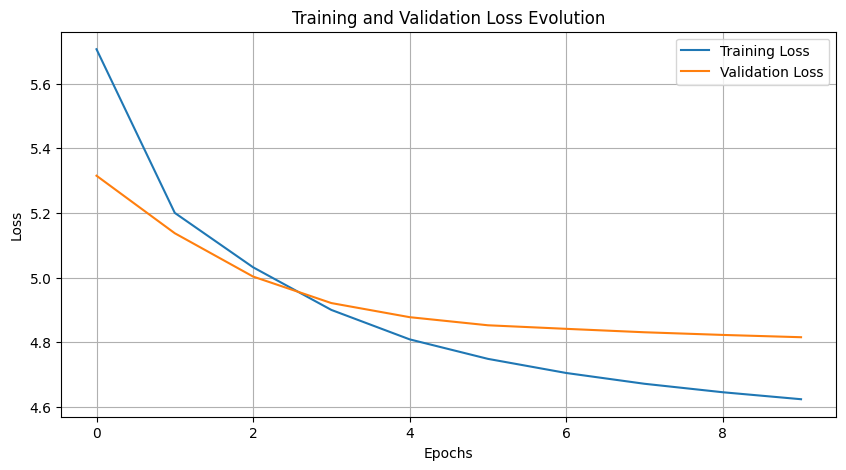

In [226]:
train(
    model=model,
    n_epochs=10,
    train_dataloader=train_dataloader,
    valid_dataloader=valid_dataloader,
    lr=5e-3,
)

🚧 **Question** 🚧

Plot the training and validation curves. What can you conclude from those curves?

**Answer**

With only 2 layers and `d_embed=64` trained for 10 epochs on 16k examples we observe:

- Both losses decrease rapidly in the first 2–3 epochs, then plateau.
- The validation loss stabilizes while the training loss continues to decrease slightly.
- The small gap between the two curves suggests mild overfitting, but not severe.
- This indicates the model is learning useful patterns but is likely limited by its capacity and training setup.


## Inference

Now that the model is trained, we can use it to generate text.

🚧 **Question** 🚧

List 3 decoding algorithms.

**Answer**

- greedy decoding
- beam search
- sampling


In [227]:
def generate(
    model,
    tokenizer,
    input_sentence: str,
    max_new_tokens: int = 20,
    mode: str = "greedy",   # "greedy" | "sampling" | "topk"
    temperature: float = 1.0,
    top_k: int = 50,
):
    model.eval()
    print("Input text:", input_sentence)

    tokenized_sentence = tokenizer.encode(input_sentence)[:-1]  # strip <EOS>
    input_ids = torch.tensor([tokenized_sentence]).to(DEVICE)
    attention_mask = torch.ones_like(input_ids)

    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits = model(input_ids, attention_mask)   # (1, l, vocab_size)
            next_token_logits = logits[0, -1]           # (vocab_size,)

            if mode == "greedy":
                # Always pick the most likely token
                next_token = next_token_logits.argmax()

            elif mode == "sampling":
                # Sample from the full distribution, with optional temperature
                # Temperature < 1 → sharper (more confident)
                # Temperature > 1 → flatter (more random)
                probs = torch.softmax(next_token_logits / temperature, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1).squeeze()

            elif mode == "topk":
                # Keep only the top-k logits, zero out the rest, then sample
                values, indices = torch.topk(next_token_logits, k=top_k)
                probs = torch.softmax(values / temperature, dim=-1)
                sampled = torch.multinomial(probs, num_samples=1).squeeze()
                next_token = indices[sampled]

            else:
                raise ValueError(f"Unknown mode: {mode}")

            input_ids = torch.cat(
                [input_ids, next_token.reshape(1, 1)], dim=-1
            )
            attention_mask = torch.ones_like(input_ids)

            decoded = tokenizer.decode(input_ids[0].tolist())
            print(decoded)

            # Stop if <EOS> was generated
            if next_token.item() == tokenizer.vocab["<EOS>"]:
                break

    return tokenizer.decode(input_ids[0].tolist())

In [228]:
y = torch.tensor([0.1, 0.3, 0.2, 0.1, 0.3])
y_topk = torch.tensor([0.3, 0.2, 0.3])
y = y_topk / y_topk.sum()
print(y)
sample = torch.multinomial(input=y, num_samples=1)

tensor([0.3750, 0.2500, 0.3750])


🚧 **TODO** 🚧

Implement greedy decoding and sampling algorithms.

In [229]:
# Greedy decoding — already implemented
output_tokens = []
model.eval()
input_sentence = "the football game"
print("Input text:", input_sentence)
tokenized_sentence = tokenizer.encode(input_sentence)[:-1]
input_ids = torch.tensor([tokenized_sentence])
attention_mask = torch.ones_like(input_ids)
print("Input tensor:", input_ids)
with torch.no_grad():
    for i in range(20):
        logits = model(input_ids.to(DEVICE), attention_mask.to(DEVICE))
        next_token = logits[0, -1].argmax().to(DEVICE)  # 0 <= argmax <= V
        input_ids = torch.cat([input_ids.to(DEVICE), next_token.reshape(1, 1)], dim=-1)
        attention_mask = torch.ones_like(input_ids)
        print(tokenizer.decode(input_ids[0].tolist()))

Input text: the football game
Input tensor: tensor([[10001,     0,  2049,   455]])
<BOS> the football game is
<BOS> the football game is a
<BOS> the football game is a good
<BOS> the football game is a good movie
<BOS> the football game is a good movie .
<BOS> the football game is a good movie . the
<BOS> the football game is a good movie . the plot
<BOS> the football game is a good movie . the plot is
<BOS> the football game is a good movie . the plot is not
<BOS> the football game is a good movie . the plot is not a
<BOS> the football game is a good movie . the plot is not a good
<BOS> the football game is a good movie . the plot is not a good movie
<BOS> the football game is a good movie . the plot is not a good movie .
<BOS> the football game is a good movie . the plot is not a good movie . the
<BOS> the football game is a good movie . the plot is not a good movie . the plot
<BOS> the football game is a good movie . the plot is not a good movie . the plot is
<BOS> the football game

In [230]:
# Sampling decoding — stochastically draw from the distribution over the vocabulary
model.eval()
input_sentence = "the football game"
print("Input text:", input_sentence)
tokenized_sentence = tokenizer.encode(input_sentence)[:-1]
input_ids = torch.tensor([tokenized_sentence])
attention_mask = torch.ones_like(input_ids)

temperature = 1.0   # higher = more random, lower = more peaked
top_k = 50         # restrict sampling to the top-k most likely tokens

with torch.no_grad():
    for i in range(20):
        logits = model(input_ids.to(DEVICE), attention_mask.to(DEVICE))
        next_logits = logits[0, -1]  # (vocab_size,)

        # Apply temperature scaling
        next_logits = next_logits / temperature

        # Top-k filtering: zero out all logits except the top-k
        topk_values, topk_indices = torch.topk(next_logits, top_k)
        filtered_logits = torch.full_like(next_logits, float("-inf"))
        filtered_logits[topk_indices] = topk_values

        # Convert to probabilities and sample
        probs = torch.softmax(filtered_logits, dim=-1)
        next_token = torch.multinomial(probs, num_samples=1)  # (1,)

        input_ids = torch.cat([input_ids.to(DEVICE), next_token.reshape(1, 1)], dim=-1)
        attention_mask = torch.ones_like(input_ids)
        print(tokenizer.decode(input_ids[0].tolist()))

Input text: the football game
<BOS> the football game is
<BOS> the football game is like
<BOS> the football game is like this
<BOS> the football game is like this time
<BOS> the football game is like this time where
<BOS> the football game is like this time where this
<BOS> the football game is like this time where this show
<BOS> the football game is like this time where this show should
<BOS> the football game is like this time where this show should be
<BOS> the football game is like this time where this show should be a
<BOS> the football game is like this time where this show should be a waste
<BOS> the football game is like this time where this show should be a waste of
<BOS> the football game is like this time where this show should be a waste of time
<BOS> the football game is like this time where this show should be a waste of time ,
<BOS> the football game is like this time where this show should be a waste of time , a
<BOS> the football game is like this time where this show

In [231]:
logits = torch.randn(10000)
logits.argmax()

tensor(5157)

A note on the three approaches and their trade-offs:

**Greedy** always picks `argmax` — fast and deterministic, but tends to produce repetitive, low-diversity text because it never takes any risk.

**Sampling** draws from the full softmax distribution. Raw sampling can produce incoherent text since low-probability tokens still get sampled occasionally. **Top-k sampling** fixes this by restricting the distribution to only the `k` most likely tokens before sampling, giving a good balance between diversity and coherence.

**Temperature** controls the sharpness of the distribution: `T < 1` makes the model more confident (less diverse), `T > 1` flattens it (more surprising but noisier). At `T → 0`, sampling converges to greedy.

🚧 **Question** 🚧

How could speed up the decoding process?

**Answer**

Cache the computation of the Key and Value in the attention mechanism.

In [232]:
class CachedGPTMHAttention(nn.Module):
    def __init__(self, d_embed, n_heads):
        super().__init__()
        self.q_proj = Linear(d_embed, d_embed, bias=False)
        self.k_proj = Linear(d_embed, d_embed, bias=False)
        self.v_proj = Linear(d_embed, d_embed, bias=False)

        assert d_embed % n_heads == 0
        self.n_heads = n_heads

        self.k_cache = None
        self.v_cache = None

    def reset_cache(self):
        self.k_cache = None
        self.v_cache = None

    def forward(self, x, attention_mask=None):
        # x: (b, 1, d)
        b, l, d_embed = x.shape
        assert l == 1, "Cache mode only supports step-by-step decoding"

        d_h = d_embed // self.n_heads

        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        # reshape to multi-head
        q = q.reshape(b, 1, self.n_heads, d_h).transpose(1, 2)  # (b, h, 1, d_h)
        k = k.reshape(b, 1, self.n_heads, d_h).transpose(1, 2)
        v = v.reshape(b, 1, self.n_heads, d_h).transpose(1, 2)

        # update cache
        if self.k_cache is None:
            self.k_cache = k
            self.v_cache = v
        else:
            self.k_cache = torch.cat([self.k_cache, k], dim=2)
            self.v_cache = torch.cat([self.v_cache, v], dim=2)

        k_full = self.k_cache
        v_full = self.v_cache

        # attention
        scores = q @ k_full.transpose(2, 3)  # (b, h, 1, L)
        scores = scores * (d_h ** -0.5)

        attn = torch.softmax(scores, dim=-1)
        y = attn @ v_full  # (b, h, 1, d_h)

        # reshape back
        y = y.transpose(1, 2).reshape(b, 1, d_embed)
        return y


def swap_attention_to_cached(model):
    for layer in model.transformer_stack:
        old_attn = layer.attention
        new_attn = CachedGPTMHAttention(model.d_embed, model.num_heads).to(DEVICE)

        # copy weights
        new_attn.q_proj.matrix.data = old_attn.q_proj.matrix.data.clone()
        new_attn.k_proj.matrix.data = old_attn.k_proj.matrix.data.clone()
        new_attn.v_proj.matrix.data = old_attn.v_proj.matrix.data.clone()

        layer.attention = new_attn

    return model


def generate_with_cache(model, tokenizer, input_sentence, max_new_tokens=20):
    model.eval()
    print("Input:", input_sentence)

    input_ids = torch.tensor([tokenizer.encode(input_sentence)[:-1]]).to(DEVICE)

    # reset cache
    for layer in model.transformer_stack:
        layer.attention.reset_cache()

    generated = input_ids

    with torch.no_grad():
        # 1. remplir le cache MANUELLEMENT (token par token)
        for i in range(generated.shape[1]):
            x = generated[:, i:i+1]  # (b,1)

            token_vec = model.token_embeddings(x)
            pos_vec = model.position_embeddings(
                torch.tensor([i], device=DEVICE)
            )[None, :, :]

            z = token_vec + pos_vec

            for layer in model.transformer_stack:
                z = layer.attention(z) + z

        logits = model.lm_head(model.out_layer_norm(z))

        # 2. génération avec cache
        for _ in range(max_new_tokens):
            next_token = logits[0, -1].argmax()

            generated = torch.cat([generated, next_token.view(1, 1)], dim=1)

            x = generated[:, -1:]

            token_vec = model.token_embeddings(x)
            pos = generated.shape[1] - 1
            pos_vec = model.position_embeddings(
                torch.tensor([pos], device=DEVICE)
            )[None, :, :]

            z = token_vec + pos_vec

            for layer in model.transformer_stack:
                z = layer.attention(z) + z

            logits = model.lm_head(model.out_layer_norm(z))

            print(tokenizer.decode(generated[0].tolist()))

            if next_token.item() == tokenizer.vocab["<EOS>"]:
                break

    return tokenizer.decode(generated[0].tolist())


model = swap_attention_to_cached(model)
generate_with_cache(model, tokenizer, "the football game")

Input: the football game
<BOS> the football game widowed
<BOS> the football game widowed abraham
<BOS> the football game widowed abraham restore
<BOS> the football game widowed abraham restore andrews
<BOS> the football game widowed abraham restore andrews brandon
<BOS> the football game widowed abraham restore andrews brandon gen
<BOS> the football game widowed abraham restore andrews brandon gen ellis
<BOS> the football game widowed abraham restore andrews brandon gen ellis simpson
<BOS> the football game widowed abraham restore andrews brandon gen ellis simpson massacre
<BOS> the football game widowed abraham restore andrews brandon gen ellis simpson massacre zellweger
<BOS> the football game widowed abraham restore andrews brandon gen ellis simpson massacre zellweger conscience
<BOS> the football game widowed abraham restore andrews brandon gen ellis simpson massacre zellweger conscience roth
<BOS> the football game widowed abraham restore andrews brandon gen ellis simpson massacre

'<BOS> the football game widowed abraham restore andrews brandon gen ellis simpson massacre zellweger conscience roth pointing mill holmes bauer captivated weary binoche longing'

During autoregressive generation, at each step we recompute K and V for all previous tokens, even though they do not change.

The solution is the KV-cache: we store past K and V tensors and only compute them for the new token, then append them to the cache.

Without cache, generating a sequence of length L requires recomputing attention over all previous tokens at each step, leading to a total computational cost of `O(L²)`.

With KV-cache, we avoid recomputing K and V. Each step only computes attention between the current query and the cached keys and values, which costs `O(L)` per step.

The total complexity remains `O(L²)`, but the constant factor is much smaller in practice, since we avoid redundant computations. This leads to a significant speedup during inference.